# Exploracion de modelos — Customer Churn

## 1. Carga de datos

In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [196]:
df = pd.read_csv("../data/raw/customer_churn_historical.csv")

print("filas, columnas:", df.shape)
df.head()

filas, columnas: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6684-LWVH,Male,0,No,No,4,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,27.56,107.47,No
1,7027-JIFO,Male,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,30.52,1020.47,No
2,5981-VOQO,Female,0,No,No,45,Yes,Yes,DSL,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),66.87,2686.35,No
3,7266-HYDM,Male,0,Yes,No,31,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),86.95,2536.96,Yes
4,2821-JDLS,Female,0,Yes,No,5,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,30.18,139.12,No


In [197]:
# Separar columnas numericas y categoricas
columnas_numericas = df.select_dtypes(include="number").columns.tolist()
columnas_categoricas = df.select_dtypes(include="object").columns.tolist()

# id y target no se usan como feature
columnas_categoricas.remove("customerID")
columnas_categoricas.remove("Churn")

print("numericas:", columnas_numericas)
print("categoricas:", columnas_categoricas)


numericas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
categoricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [198]:
# Columna nueva: Yes -> 1, No -> 0
df["churn_0_1"] = 0
df.loc[df["Churn"] == "Yes", "churn_0_1"] = 1

print(df[["Churn", "churn_0_1"]].head())


  Churn  churn_0_1
0    No          0
1    No          0
2    No          0
3   Yes          1
4    No          0


In [199]:
y = df["churn_0_1"]

# El id y el target no se usan como predictor
X = df.drop(columns=["Churn", "churn_0_1", "customerID"])

print("Cantidad de clientes por clase (0=No churn, 1=Churn):")
print(y.value_counts())
print()
print("Proporcion por clase:")
print(y.value_counts(normalize=True).round(2))
print()
print("Filas en X:", len(X))
print("Filas en y:", len(y))


Cantidad de clientes por clase (0=No churn, 1=Churn):
churn_0_1
0    5186
1    1857
Name: count, dtype: int64

Proporcion por clase:
churn_0_1
0    0.74
1    0.26
Name: proportion, dtype: float64

Filas en X: 7043
Filas en y: 7043


In [200]:
# Particion train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,random_state=42, stratify=y)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 5634
Test: 1409


## 2. Preprocessing

Imputacion, encoding y escalado van adentro del Pipeline.
Lo armamos una vez y lo reusamos en cada modelo.


In [201]:
# Numericas: mediana + escalado
pipe_num = Pipeline(
    steps=[
        ("imputar", SimpleImputer(strategy="median")),
        ("escalar", StandardScaler()),
    ]
)

# Categoricas: moda + one-hot
pipe_cat = Pipeline(
    steps=[
        ("imputar", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocesador = ColumnTransformer(
    transformers=[
        ("num", pipe_num, columnas_numericas),
        ("cat", pipe_cat, columnas_categoricas),
    ]
)


## 3. Baseline — DummyClassifier

In [202]:
# Siempre predice No churn. No usa las features: es el piso.
modelo_baseline = DummyClassifier(strategy="most_frequent")
modelo_baseline.fit(X_train, y_train)

pred_baseline = modelo_baseline.predict(X_test)
proba_baseline = modelo_baseline.predict_proba(X_test)[:, 1]

print("accuracy:", round(accuracy_score(y_test, pred_baseline), 3))
print("precision:", round(precision_score(y_test, pred_baseline, zero_division=0), 3))
print("recall:", round(recall_score(y_test, pred_baseline, zero_division=0), 3))
print("f1:", round(f1_score(y_test, pred_baseline, zero_division=0), 3))
print("roc_auc:", round(roc_auc_score(y_test, proba_baseline), 3))
print("matriz_confusion:")
print(confusion_matrix(y_test, pred_baseline))


accuracy: 0.736
precision: 0.0
recall: 0.0
f1: 0.0
roc_auc: 0.5
matriz_confusion:
[[1037    0]
 [ 372    0]]


## 4. Regresion logistica


In [203]:
# Crear modelo lineal
modelo_logreg = LogisticRegression(max_iter=1000, C=1.0, random_state=42)

pipe_logreg = Pipeline(
    steps=[
        ("preprocesar", preprocesador),
        ("modelo", modelo_logreg),
    ]
)

pipe_logreg.fit(X_train, y_train)

pred_logreg = pipe_logreg.predict(X_test)
proba_logreg = pipe_logreg.predict_proba(X_test)[:, 1]

print("accuracy:", round(accuracy_score(y_test, pred_logreg), 3))
print("precision:", round(precision_score(y_test, pred_logreg, zero_division=0), 3))
print("recall:", round(recall_score(y_test, pred_logreg, zero_division=0), 3))
print("f1:", round(f1_score(y_test, pred_logreg, zero_division=0), 3))
print("roc_auc:", round(roc_auc_score(y_test, proba_logreg), 3))
print("matriz_confusion:")
print(confusion_matrix(y_test, pred_logreg))


accuracy: 0.794
precision: 0.663
recall: 0.449
f1: 0.535
roc_auc: 0.812
matriz_confusion:
[[952  85]
 [205 167]]


## 5. Random Forest


In [204]:
# Modelo de arboles
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

pipe_rf = Pipeline(
    steps=[
        ("preprocesar", preprocesador),
        ("modelo", modelo_rf),
    ]
)

pipe_rf.fit(X_train, y_train)

pred_rf = pipe_rf.predict(X_test)
proba_rf = pipe_rf.predict_proba(X_test)[:, 1]

print("accuracy:", round(accuracy_score(y_test, pred_rf), 3))
print("precision:", round(precision_score(y_test, pred_rf, zero_division=0), 3))
print("recall:", round(recall_score(y_test, pred_rf, zero_division=0), 3))
print("f1:", round(f1_score(y_test, pred_rf, zero_division=0), 3))
print("roc_auc:", round(roc_auc_score(y_test, proba_rf), 3))
print("matriz_confusion:")
print(confusion_matrix(y_test, pred_rf))


accuracy: 0.783
precision: 0.642
recall: 0.401
f1: 0.493
roc_auc: 0.79
matriz_confusion:
[[954  83]
 [223 149]]


## 6. Tabla comparativa


In [205]:
# Armar una tabla con las metricas de cada modelo
resultados = []

resultados.append(
    {
        "modelo": "baseline",
        "accuracy": accuracy_score(y_test, pred_baseline),
        "precision": precision_score(y_test, pred_baseline, zero_division=0),
        "recall": recall_score(y_test, pred_baseline, zero_division=0),
        "f1": f1_score(y_test, pred_baseline, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba_baseline),
    }
)
resultados.append(
    {
        "modelo": "logreg",
        "accuracy": accuracy_score(y_test, pred_logreg),
        "precision": precision_score(y_test, pred_logreg, zero_division=0),
        "recall": recall_score(y_test, pred_logreg, zero_division=0),
        "f1": f1_score(y_test, pred_logreg, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba_logreg),
    }
)
resultados.append(
    {
        "modelo": "rf",
        "accuracy": accuracy_score(y_test, pred_rf),
        "precision": precision_score(y_test, pred_rf, zero_division=0),
        "recall": recall_score(y_test, pred_rf, zero_division=0),
        "f1": f1_score(y_test, pred_rf, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba_rf),
    }
)

tabla = pd.DataFrame(resultados)
tabla = tabla.round(3)
tabla


,modelo,accuracy,precision,recall,f1,roc_auc
0,baseline,0.736,0.000,0.000,0.000,0.500
1,logreg,0.794,0.663,0.449,0.535,0.812
2,rf,0.783,0.642,0.401,0.493,0.790


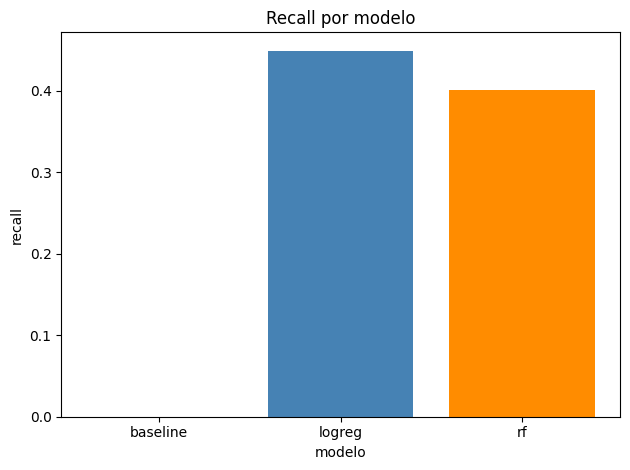

In [206]:
# Grafico de recall por modelo
colores_recall = ["gray", "steelblue", "darkorange"]

plt.bar(tabla["modelo"], tabla["recall"], color=colores_recall)
plt.title("Recall por modelo")
plt.ylabel("recall")
plt.xlabel("modelo")
plt.tight_layout()
plt.show()


## 7. Decision

- **baseline:** recall 0. Accuracy ~0.74 sin detectar abandonos.
- **logreg:** mejora recall y AUC respecto del piso.
- **rf:** alternativa de arboles; comparar en la tabla.

Candidato de esta exploracion: **logreg**.
